# 0 - SETUP & MOUNT DRIVE

In [ ]:
# [0.1] Cài gdown và download data từ Google Drive (không cần mount)
!pip install gdown --quiet
import gdown, os, glob

os.makedirs('/content/data', exist_ok=True)

# Download cả folder Drive (public link)
gdown.download_folder(
    id='1ufqunCqKjuNo1TcLYapcPtEma5NkZubF',
    output='/content/data',
    quiet=False,
    use_cookies=False
)

print('\n✅ Download xong! Files:')
for f in sorted(glob.glob('/content/data/*')):
    size = os.path.getsize(f) / 1024 / 1024
    print(f'  {os.path.basename(f):55s} {size:.1f} MB')

Retrieving folder contents


Processing file 1sQ1NbnNhrLpJ4Dnzys9cJ_qpDBMY_o6w ILIARIRates.csv
Processing file 1J4zjnUSSt_iCBVhg_hGNZQZydqcR3V_q influenza_weekly.csv
Processing file 10d593ntFt5TX4k8UF-nHZySJlGV0DkHR National_extract_V1_3.csv
Processing file 15oGlvSFtPvOuknHGPBdHNJmIJ-uh6ush SARIRates.csv
Processing file 1r24fyMy5SAHobeqG4QbsReyo-2xfRo8_ SARITestsDetectionsPositivity.csv
Processing file 1BNc2te5xspExkE37CKrt9_u2quRzVdTG sentinelTestsDetectionsPositivity.csv
Processing file 1AWXe9SnEYcFxaCxVIZ9kVaSEAa-9P_pZ test_era5.py
Processing file 1bT4gLIrOzSnZyAg3ie0VaQ3Wzdx6-siC VIW_FLU_METADATA.csv
Processing file 1AB9fFYwAkuDiUi5_rdw0hrkPTsohOBRD VIW_FNT.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1sQ1NbnNhrLpJ4Dnzys9cJ_qpDBMY_o6w
To: /content/data/ILIARIRates.csv
100%|██████████| 2.81M/2.81M [00:00<00:00, 97.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1J4zjnUSSt_iCBVhg_hGNZQZydqcR3V_q
To: /content/data/influenza_weekly.csv
100%|██████████| 4.82M/4.82M [00:00<00:00, 65.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=10d593ntFt5TX4k8UF-nHZySJlGV0DkHR
To: /content/data/National_extract_V1_3.csv
100%|██████████| 3.58M/3.58M [00:00<00:00, 116MB/s]
Downloading...
From: https://drive.google.com/uc?id=15oGlvSFtPvOuknHGPBdHNJmIJ-uh6ush
To: /content/data/SARIRates.csv
100%|██████████| 567k/567k [00:00<00:00, 58.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1r24fyMy5SAHobeqG4QbsReyo-2xfRo8_
To: /content/data/SARITestsDetectionsPositivity.csv
100%|██████████| 2.16M/2.16M [00:00<00:00, 139MB/s]
Dow


✅ Download xong! Files:
  ILIARIRates.csv                                         2.7 MB
  National_extract_V1_3.csv                               3.4 MB
  SARIRates.csv                                           0.5 MB
  SARITestsDetectionsPositivity.csv                       2.1 MB
  VIW_FLU_METADATA.csv                                    0.0 MB
  VIW_FNT.csv                                             29.7 MB
  influenza_weekly.csv                                    4.6 MB
  sentinelTestsDetectionsPositivity.csv                   4.3 MB
  test_era5.py                                            0.0 MB



Download completed


In [2]:
# [0.2] Cài thư viện cần thiết
!pip install xarray netcdf4 prophet pandas --quiet

In [3]:
# [ECDC_EXTRA] Khám phá các file ECDC còn lại
import os
import pandas as pd

ECDC_DIR = '/content/data'  # hoặc đường dẫn folder ECDC trên máy bạn

extra_files = [
    'SARIRates.csv',
    'SARITestsDetectionsPositivity.csv',
    'nonSentinelTestsDetections.csv',
    'nonSentinelSeverity.csv',
    'activityFluTypeSubtype.csv',
    'sequencingVolumeDetectablePrevalence.csv',
    'variants.csv',
]

for fname in extra_files:
    fpath = os.path.join(ECDC_DIR, fname)
    if not os.path.exists(fpath):
        print(f'❌ {fname} — không tìm thấy')
        continue
    df = pd.read_csv(fpath, nrows=3)
    size = os.path.getsize(fpath) / 1024
    print(f'\n{"="*55}')
    print(f'📄 {fname} ({size:.0f} KB)')
    print(f'   Shape (3 rows): {df.shape} | Columns: {list(df.columns)}')
    print(df.head(2).to_string())


📄 SARIRates.csv (554 KB)
   Shape (3 rows): (3, 6) | Columns: ['survtype', 'countryname', 'yearweek', 'indicator', 'age', 'value']
         survtype countryname  yearweek indicator    age  value
0  SARI syndromic     Austria  2026-W15  SARIrate    0-4   18.5
1  SARI syndromic     Austria  2026-W15  SARIrate  15-64    1.3

📄 SARITestsDetectionsPositivity.csv (2109 KB)
   Shape (3 rows): (3, 9) | Columns: ['survtype', 'countryname', 'yearweek', 'pathogen', 'pathogentype', 'pathogensubtype', 'indicator', 'age', 'value']
           survtype countryname  yearweek   pathogen pathogentype pathogensubtype   indicator    age  value
0  SARI virological     Belgium  2026-W14  Influenza    Influenza           total  detections  total    3.0
1  SARI virological     Belgium  2026-W14  Influenza    Influenza           total  positivity  total    2.5
❌ nonSentinelTestsDetections.csv — không tìm thấy
❌ nonSentinelSeverity.csv — không tìm thấy
❌ activityFluTypeSubtype.csv — không tìm thấy
❌ sequencingV

- SARIRates.csv (554KB) — Tỷ lệ nhập viện do hội chứng hô hấp cấp nặng (SARI) theo tuần, có breakdown theo age group. Đây là chỉ số severity quan trọng mà FluNet không có — khi số ca tăng cao thì SARI rate cho biết mức độ nghiêm trọng. Có thể dùng làm target phụ hoặc feature cho hệ thống cảnh báo mức độ.

- SARITestsDetectionsPositivity.csv (2.1MB) — Xét nghiệm + phát hiện Influenza/RSV trong bệnh nhân SARI nhập viện. Cấu trúc giống sentinelTestsDetectionsPositivity.csv nhưng từ nguồn SARI (bệnh viện) thay vì sentinel (phòng khám). Kết hợp với SARIRates sẽ cho picture đầy đủ về severity.

In [4]:
# [0.3] Import tất cả thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('✅ Import xong!')

✅ Import xong!


In [5]:
# [0.4] Định nghĩa đường dẫn — THAY TÊN FOLDER NẾU KHÁC
# ⚠️ File nằm ở Google Drive khác → dùng gdown, không mount
# Sau khi chạy cell [0.1], tất cả file nằm tại /content/data/
BASE = Path('/content/data')

FILES = {
    'flunet'   : BASE / 'VIW_FNT.csv',
    'flu_meta' : BASE / 'VIW_FLU_METADATA.csv',
    'flu_bak'  : BASE / 'influenza_weekly.csv',
    'dengue'   : BASE / 'National_extract_V1_3.csv',
    'ecdc_sen' : BASE / 'sentinelTestsDetectionsPositivity.csv',
    'ecdc_ili' : BASE / 'ILIARIRates.csv',
}

print('Kiểm tra files:')
for name, path in FILES.items():
    status = '✅' if path.exists() else '❌ KHÔNG TÌM THẤY'
    print(f'  {status}  {name:12s} → {path.name}')

Kiểm tra files:
  ✅  flunet       → VIW_FNT.csv
  ✅  flu_meta     → VIW_FLU_METADATA.csv
  ✅  flu_bak      → influenza_weekly.csv
  ✅  dengue       → National_extract_V1_3.csv
  ✅  ecdc_sen     → sentinelTestsDetectionsPositivity.csv
  ✅  ecdc_ili     → ILIARIRates.csv


# 1 — LOAD & INSPECT RAW DATA

> Mục tiêu: Hiểu cấu trúc từng file, phát hiện vấn đề sớm
>

> 📌 **KẾT LUẬN SESSION 1** (19/04/2026)
>

> - **FluNet**: 183,026 dòng, 53 cột, 189 quốc gia, 1995–2026 ✅. Có nhiều cột subtype chi tiết hơn dự kiến (AH1N12009, AH3, BVIC_2DEL...). Có cả RSV_PROCESSED và RSV — cần kiểm tra sự khác biệt ở SESSION 2.
>

> - **OpenDengue**: 29,873 dòng, Week chiếm 23,248 — đủ granularity ✅. Date format dạng MM/DD/YYYY (ví dụ: '9/5/2021'), cần dùng `format='mixed'` khi parse.
>

> - **ECDC Sentinel**: 54,827 dòng, 30 quốc gia, có cả SARS-CoV-2 — filter bỏ khi dùng ✅
>

> - **ECDC ILI**: 39,414 dòng, có đủ age groups (0-4, 5-14, 15-64, 65+, total) ✅
>

> - **influenza_weekly.csv**: Là FluNet phiên bản cũ từ nguồn khác (có cột TITLE='Sporadic', FLUREGION, REPORT_ID). Cấu trúc khác VIW_FNT.csv → **QUYẾT ĐỊNH: bỏ qua, dùng VIW_FNT.csv làm nguồn chính**
>

In [6]:
# [1.1] Load FluNet
flu = pd.read_csv(FILES['flunet'], low_memory=False)
print(f'Shape: {flu.shape}')
print(f'Columns: {list(flu.columns)}')
print(f'Years: {flu["ISO_YEAR"].min()} – {flu["ISO_YEAR"].max()}')
print(f'Countries: {flu["COUNTRY_CODE"].nunique()}')
flu.head(3)

Shape: (183026, 53)
Columns: ['WHOREGION', 'FLUSEASON', 'HEMISPHERE', 'ITZ', 'COUNTRY_CODE', 'COUNTRY_AREA_TERRITORY', 'ISO_WEEKSTARTDATE', 'ISO_YEAR', 'ISO_WEEK', 'MMWR_WEEKSTARTDATE', 'MMWR_YEAR', 'MMWR_WEEK', 'ORIGIN_SOURCE', 'SPEC_PROCESSED_NB', 'SPEC_RECEIVED_NB', 'AH1N12009', 'AH1', 'AH3', 'AH5', 'AH7N9', 'ANOTSUBTYPED', 'ANOTSUBTYPABLE', 'AOTHER_SUBTYPE', 'AOTHER_SUBTYPE_DETAILS', 'INF_A', 'BVIC_2DEL', 'BVIC_3DEL', 'BVIC_NODEL', 'BVIC_DELUNK', 'BYAM', 'BNOTDETERMINED', 'INF_B', 'INF_ALL', 'INF_NEGATIVE', 'ILI_ACTIVITY', 'ADENO', 'BOCA', 'HUMAN_CORONA', 'METAPNEUMO', 'PARAINFLUENZA', 'RHINO', 'RSV_PROCESSED', 'RSV', 'OTHERRESPVIRUS', 'OTHER_RESPVIRUS_DETAILS', 'LAB_RESULT_COMMENT', 'WCR_COMMENT', 'ISO2', 'ISOYW', 'MMWRYW', 'PSOURCE_SUBTYPE_INF', 'PSOURCE_PPOS_INF', 'PSOURCE_RSV']
Years: 1995 – 2026
Countries: 189


,WHOREGION,FLUSEASON,HEMISPHERE,ITZ,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,MMWR_WEEKSTARTDATE,...,OTHERRESPVIRUS,OTHER_RESPVIRUS_DETAILS,LAB_RESULT_COMMENT,WCR_COMMENT,ISO2,ISOYW,MMWRYW,PSOURCE_SUBTYPE_INF,PSOURCE_PPOS_INF,PSOURCE_RSV
0,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-02,2017,1,2017-01-01,...,NaN,NaN,NaN,NaN,AW,201701,201701,NaN,NaN,NaN
1,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-09,2017,2,2017-01-08,...,NaN,NaN,NaN,NaN,AW,201702,201702,NaN,NaN,NaN
2,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-16,2017,3,2017-01-15,...,NaN,NaN,NaN,NaN,AW,201703,201703,NaN,NaN,NaN


📌 **[1.1]** FluNet có 53 cột, nhiều hơn dự kiến — WHO tách rất chi tiết theo subtype (AH1N12009, AH3, BVIC_2DEL...). Với mục tiêu hiện tại chỉ cần INF_A + INF_B, nhưng các cột subtype này có thể hữu ích nếu sau này muốn phân tích theo chủng cụ thể. Lưu ý có 2 cột RSV tên gần giống nhau (`RSV` vs `RSV_PROCESSED`) — chưa rõ khác nhau như thế nào, cần làm rõ ở [2.1].

In [7]:
# [1.2] Load OpenDengue
dengue = pd.read_csv(FILES['dengue'], low_memory=False)
print(f'Shape: {dengue.shape}')
print(f'T_res:\n{dengue["T_res"].value_counts()}')
dengue.head(3)

Shape: (29873, 16)
T_res:
T_res
Week     23248
Year      3495
Month     3130
Name: count, dtype: int64


,adm_0_name,adm_1_name,adm_2_name,full_name,ISO_A0,FAO_GAUL_code,RNE_iso_code,IBGE_code,calendar_start_date,calendar_end_date,Year,dengue_total,case_definition_standardised,S_res,T_res,UUID
0,AFGHANISTAN,NaN,NaN,AFGHANISTAN,AFG,1011446,AFG,NaN,9/5/2021,9/11/2021,2021,18.0,Suspected,Admin0,Week,WHOEMRO-ALL-2021-Y01-05
1,AFGHANISTAN,NaN,NaN,AFGHANISTAN,AFG,1011446,AFG,NaN,9/12/2021,9/18/2021,2021,24.0,Suspected,Admin0,Week,WHOEMRO-ALL-2021-Y01-05
2,AFGHANISTAN,NaN,NaN,AFGHANISTAN,AFG,1011446,AFG,NaN,9/19/2021,9/25/2021,2021,9.0,Suspected,Admin0,Week,WHOEMRO-ALL-2021-Y01-05


📌 **[1.2]** Date lưu dạng MM/DD/YYYY kiểu Mỹ — bẫy phổ biến với dataset tổng hợp đa quốc gia, parse thông thường sẽ bị nhầm ngày hoặc lỗi, phải dùng `format='mixed'`. Granularity ổn: Week chiếm 78% (23K/29K dòng).


In [8]:
# [1.3] Load ECDC Sentinel
ecdc_sen = pd.read_csv(FILES['ecdc_sen'], low_memory=False)
print(f'Shape: {ecdc_sen.shape}')
print(f'Pathogens: {ecdc_sen["pathogen"].unique()}')
print(f'Indicators: {ecdc_sen["indicator"].unique()}')
print(f'Countries: {ecdc_sen["countryname"].nunique()}')
ecdc_sen.head(3)

Shape: (54827, 9)
Pathogens: ['Influenza' 'RSV' 'SARS-CoV-2']
Indicators: ['detections' 'positivity' 'tests']
Countries: 30


,survtype,countryname,yearweek,pathogen,pathogentype,pathogensubtype,indicator,age,value
0,primary care sentinel,Austria,2026-W15,Influenza,Influenza,total,detections,total,0.0
1,primary care sentinel,Austria,2026-W15,Influenza,Influenza,total,positivity,total,0.0
2,primary care sentinel,Austria,2026-W15,Influenza,Influenza,total,tests,total,88.0


📌 **[1.3]** Từ 2021 ECDC gộp SARS-CoV-2 vào cùng pipeline báo cáo với Influenza và RSV — phản ánh xu hướng tích hợp giám sát hô hấp hậu COVID. Không ảnh hưởng đến việc dùng, chỉ cần filter bỏ. Phạm vi chỉ 30 quốc gia EU/EEA nên đây là nguồn bổ sung khu vực châu Âu, không thay thế được FluNet toàn cầu (189 quốc gia).

In [9]:
# [1.4] Load ECDC ILI Rates
ecdc_ili = pd.read_csv(FILES['ecdc_ili'], low_memory=False)
print(f'Shape: {ecdc_ili.shape}')
ecdc_ili.head(3)

Shape: (39414, 6)


,survtype,countryname,yearweek,indicator,age,value
0,primary care syndromic,Austria,2026-W14,ILIconsultationrate,0-4,857.6
1,primary care syndromic,Austria,2026-W14,ILIconsultationrate,15-64,3801.8
2,primary care syndromic,Austria,2026-W14,ILIconsultationrate,5-14,79.2


📌 **[1.4]** Điểm mạnh so với FluNet là có breakdown theo 5 nhóm tuổi (0-4, 5-14, 15-64, 65+, total). Tỷ lệ ca nhóm 65+ thường là chỉ số tốt cho mức độ nghiêm trọng của mùa cúm — có thể tích hợp làm feature phụ sau khi xong phần core.

In [10]:
# [1.5] Kiểm tra influenza_weekly.csv là file gì
flu_bak = pd.read_csv(FILES['flu_bak'], nrows=5)
print('influenza_weekly.csv — 5 dòng đầu:')
print(flu_bak)
print(f'Columns: {list(flu_bak.columns)}')

influenza_weekly.csv — 5 dòng đầu:
   REPORT_ID      Country                            WHOREGION      FLUREGION  \
0       1048  Afghanistan  Eastern Mediterranean Region of WHO  Southern Asia   
1       1059  Afghanistan  Eastern Mediterranean Region of WHO  Southern Asia   
2       1060  Afghanistan  Eastern Mediterranean Region of WHO  Southern Asia   
3       1061  Afghanistan  Eastern Mediterranean Region of WHO  Southern Asia   
4       1062  Afghanistan  Eastern Mediterranean Region of WHO  Southern Asia   

   Year  Week  SDATE  EDATE  SPEC_RECEIVED_NB  SPEC_PROCESSED_NB  ...  AH5  \
0  2015     5  42030  42036                43                 43  ...    0   
1  2015    16  42107  42113                22                 22  ...    0   
2  2015    17  42114  42120                26                 26  ...    0   
3  2015    18  42121  42127                17                 17  ...    0   
4  2015    19  42128  42134                23                 23  ...    0   

   ANOTSU

📌 **[1.5]** Là FluNet phiên bản cũ từ hệ thống báo cáo khác của WHO — có cột REPORT_ID, FLUREGION, TITLE (='Sporadic'). Cấu trúc cột khác hoàn toàn VIW_FNT.csv, không merge trực tiếp được. Vì VIW_FNT.csv đã đầy đủ và mới hơn nên quyết định bỏ qua file này.

# 2 — DATA QUALITY CHECK

In [11]:
# [2.1] FluNet — Missing rate các cột quan trọng
COLS_FLU = ['COUNTRY_CODE','ISO_YEAR','ISO_WEEK',
            'INF_A','INF_B','INF_ALL',
            'ILI_ACTIVITY','RSV','RSV_PROCESSED','PARAINFLUENZA','SPEC_PROCESSED_NB']

print('FluNet — Missing rate (%):')
for c in COLS_FLU:
    if c in flu.columns:
        miss = flu[c].isna().mean() * 100
        bar = '█' * int(miss/5)
        print(f'  {c:25s}: {miss:5.1f}%  {bar}')

FluNet — Missing rate (%):
  COUNTRY_CODE             :   0.0%  
  ISO_YEAR                 :   0.0%  
  ISO_WEEK                 :   0.0%  
  INF_A                    :  12.9%  ██
  INF_B                    :  12.1%  ██
  INF_ALL                  :  44.3%  ████████
  ILI_ACTIVITY             :  60.0%  ████████████
  RSV                      :  52.1%  ██████████
  RSV_PROCESSED            :  81.9%  ████████████████
  PARAINFLUENZA            :  85.5%  █████████████████
  SPEC_PROCESSED_NB        :   7.0%  █


📌 **[2.1]** Missing rate chia 2 nhóm rõ:
- Dùng được: COUNTRY_CODE/ISO_YEAR/ISO_WEEK (0%), SPEC_PROCESSED_NB (7%), INF_A (12.9%), INF_B (12.1%)
- Quá thưa: INF_ALL (44.3%), ILI_ACTIVITY (60%), RSV (52%), PARAINFLUENZA (85.5%)

INF_ALL missing 44% không dùng làm target được — thay bằng `INF_A + INF_B`, fillna(0) hợp lý vì missing ở đây thường nghĩa là quốc gia không gửi báo cáo tuần đó chứ không phải không có ca bệnh.


In [12]:
# RSV vs RSV_PROCESSED
print('\n--- RSV vs RSV_PROCESSED ---')
print(flu[['RSV','RSV_PROCESSED']].describe())
print('\nCorrelation:', flu[['RSV','RSV_PROCESSED']].corr().iloc[0,1].round(3))


--- RSV vs RSV_PROCESSED ---
                RSV  RSV_PROCESSED
count  87704.000000   33159.000000
mean      21.998951     640.952321
std      126.250572    2592.729753
min        0.000000       0.000000
25%        0.000000       0.000000
50%        0.000000      14.000000
75%        4.000000     114.000000
max     4120.000000   47529.000000

Correlation: 0.729


RSV vs RSV_PROCESSED: correlation 0.729, đơn vị khác hẳn (ca phát hiện vs mẫu xử lý) — chỉ giữ RSV. PARAINFLUENZA 85.5% missing — loại khỏi model chính.

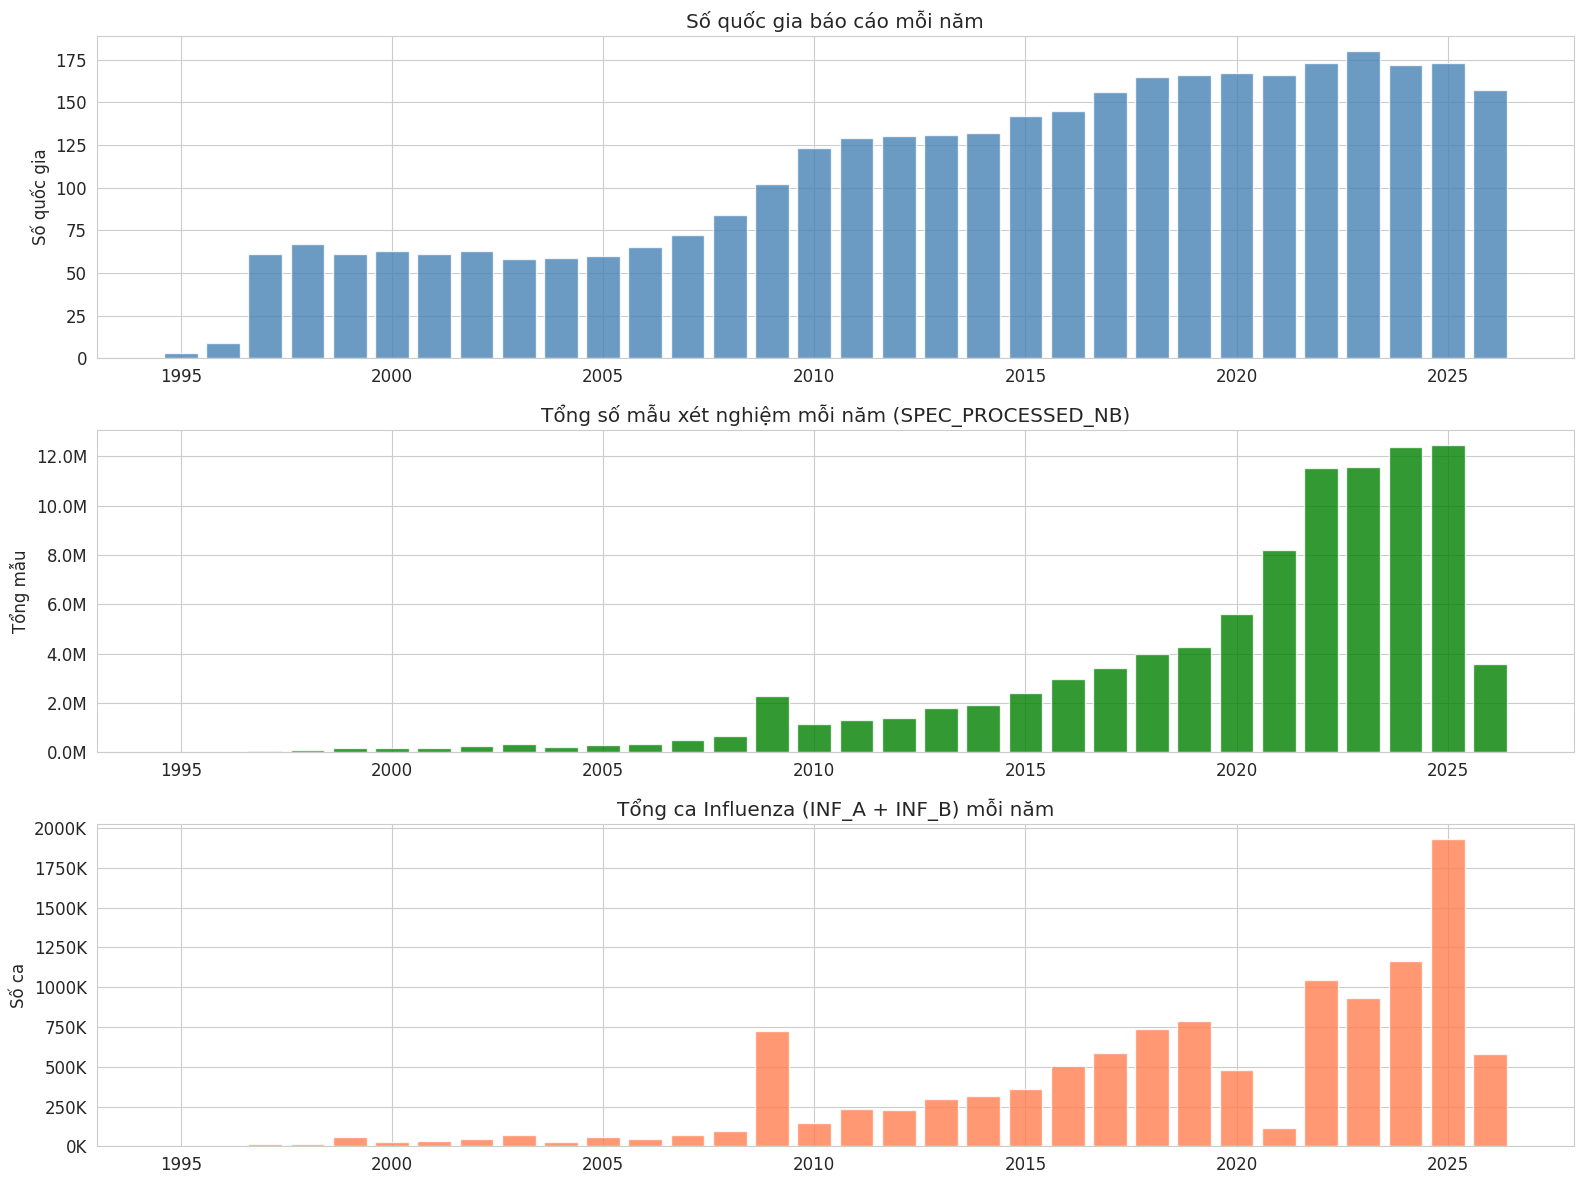

 Năm | Quốc gia |     Tổng mẫu |  Tổng ca INF
---------------------------------------------
1995 |        3 |        1,057 |          411
1996 |        9 |        1,607 |        1,909
1997 |       61 |       38,701 |       12,801
1998 |       67 |       77,765 |       13,522
1999 |       61 |      190,835 |       58,674
2000 |       63 |      167,139 |       24,276
2001 |       61 |      187,032 |       31,665
2002 |       63 |      266,165 |       47,779
2003 |       58 |      355,666 |       70,405
2004 |       59 |      224,153 |       29,866
2005 |       60 |      309,293 |       57,312
2006 |       65 |      340,847 |       45,590
2007 |       72 |      502,552 |       71,592
2008 |       84 |      655,508 |       98,532
2009 |      102 |    2,282,473 |      723,085
2010 |      123 |    1,147,690 |      149,054
2011 |      129 |    1,329,583 |      232,793
2012 |      130 |    1,389,585 |      227,151
2013 |      131 |    1,797,113 |      295,748
2014 |      132 |    1,933,529 |  

In [13]:
# [2.2] Phân tích để QUYẾT ĐỊNH khoảng train — không hardcode
coverage    = flu.groupby('ISO_YEAR')['COUNTRY_CODE'].nunique()
avg_reports = flu.groupby('ISO_YEAR')['SPEC_PROCESSED_NB'].sum()
inf_total_yr = flu.groupby('ISO_YEAR').apply(
    lambda x: (x['INF_A'].fillna(0) + x['INF_B'].fillna(0)).sum()
)

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].bar(coverage.index, coverage.values, color='steelblue', alpha=0.8)
axes[0].set_title('Số quốc gia báo cáo mỗi năm')
axes[0].set_ylabel('Số quốc gia')

axes[1].bar(avg_reports.index, avg_reports.values, color='green', alpha=0.8)
axes[1].set_title('Tổng số mẫu xét nghiệm mỗi năm (SPEC_PROCESSED_NB)')
axes[1].set_ylabel('Tổng mẫu')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

axes[2].bar(inf_total_yr.index, inf_total_yr.values, color='coral', alpha=0.8)
axes[2].set_title('Tổng ca Influenza (INF_A + INF_B) mỗi năm')
axes[2].set_ylabel('Số ca')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

# Bảng số liệu để quyết định
print(f'{"Năm":>4} | {"Quốc gia":>8} | {"Tổng mẫu":>12} | {"Tổng ca INF":>12}')
print('-'*45)
for yr in sorted(flu['ISO_YEAR'].unique()):
    n_ctry = coverage.get(yr, 0)
    n_spec = avg_reports.get(yr, 0)
    n_inf  = inf_total_yr.get(yr, 0)
    flag   = ' ← COVID' if yr in [2020, 2021] else ''
    print(f'{yr:>4} | {n_ctry:>8} | {n_spec:>12,.0f} | {n_inf:>12,.0f}{flag}')

📌 **[2.2]** 3 plot kết hợp cho thấy rõ 3 giai đoạn:
- 1995–2009: coverage thấp, hệ thống đang mở rộng, data không ổn định. Năm 2009 đột biến do H1N1 pandemic (723K ca) — không đại diện pattern mùa thông thường.
- 2010–2019: coverage ổn định 120–165 quốc gia, tổng mẫu tăng đều — giai đoạn giám sát bình thường, phù hợp nhất để train.
- 2020–2021: COVID làm Influenza gần như biến mất (chỉ 114K ca năm 2021 do giãn cách + khẩu trang) — nếu train vào đây model sẽ học pattern sai.
- 2022–2025: bounce-back do "immunity debt" sau COVID, số ca vọt lên 1–1.9M — cũng bất thường so với baseline.

→ Chốt: `TRAIN_START=2010`, `TRAIN_END=2019`, `COVID_YEARS=[2020,2021]` excluded, `VAL_YEAR=2022`.

In [14]:
# [2.3] OpenDengue — Missing & coverage
print('OpenDengue — Missing rate:')
for c in ['dengue_total','calendar_start_date','ISO_A0','Year']:
    miss = dengue[c].isna().mean() * 100
    print(f'  {c:25s}: {miss:.1f}%')

print(f'\nCountries: {dengue["ISO_A0"].nunique()}')
print(f'Years: {dengue["Year"].min()} – {dengue["Year"].max()}')
print(f'\nT_res breakdown:\n{dengue["T_res"].value_counts()}')

# Dengue date format check
dengue_wm = dengue[dengue['T_res'].isin(['Week','Month'])].copy()
print(f'\nSample dates: {dengue_wm["calendar_start_date"].head(3).tolist()}')

# Parse với format='mixed' để handle MM/DD/YYYY
dengue_wm['date_parsed'] = pd.to_datetime(dengue_wm['calendar_start_date'], format='mixed', dayfirst=False)
print(f'Parse thành công: {dengue_wm["date_parsed"].notna().sum():,} / {len(dengue_wm):,}')
print(f'Sample parsed: {dengue_wm["date_parsed"].head(3).tolist()}')

OpenDengue — Missing rate:
  dengue_total             : 0.0%
  calendar_start_date      : 0.0%
  ISO_A0                   : 0.0%
  Year                     : 0.0%

Countries: 129
Years: 1924 – 2025

T_res breakdown:
T_res
Week     23248
Year      3495
Month     3130
Name: count, dtype: int64

Sample dates: ['9/5/2021', '9/12/2021', '9/19/2021']
Parse thành công: 26,378 / 26,378
Sample parsed: [Timestamp('2021-09-05 00:00:00'), Timestamp('2021-09-12 00:00:00'), Timestamp('2021-09-19 00:00:00')]


📌 **[2.3]** Missing 0% tất cả cột quan trọng, parse date thành công 100%. Train set có 19,323 rows, 93 quốc gia. Vấn đề lớn nhất là Brazil chiếm 10.49M ca trong khi Indonesia đứng thứ 2 chỉ 1.32M — chênh lệch 8x. Nếu không xử lý model sẽ bị dominated bởi Brazil, các nước nhỏ hơn bị bỏ qua. Giải pháp: dùng `log1p` transform trước khi train.

In [15]:
# [2.4] OpenDengue — Coverage quốc gia theo năm
dengue_train = dengue_wm[dengue_wm['Year'].between(2010, 2022)]
print(f'Dengue train 2010-2022: {len(dengue_train):,} rows, {dengue_train["ISO_A0"].nunique()} countries')

# Top 10 quốc gia nhiều ca nhất
top10 = dengue_train.groupby('adm_0_name')['dengue_total'].sum().nlargest(10)
print(f'\nTop 10 quốc gia nhiều ca Dengue nhất (2010-2022):')
for name, val in top10.items():
    print(f'  {name:20s}: {val/1e6:.2f}M ca')

Dengue train 2010-2022: 19,323 rows, 93 countries

Top 10 quốc gia nhiều ca Dengue nhất (2010-2022):
  BRAZIL              : 10.49M ca
  INDONESIA           : 1.32M ca
  MEXICO              : 0.88M ca
  THAILAND            : 0.74M ca
  SRI LANKA           : 0.73M ca
  NICARAGUA           : 0.64M ca
  COLOMBIA            : 0.60M ca
  MALAYSIA            : 0.60M ca
  PHILIPPINES         : 0.55M ca
  PERU                : 0.33M ca


In [16]:
# [2.5] ECDC — Overview & coverage
print('ECDC Sentinel:')
print(f'  Yearweek: {ecdc_sen["yearweek"].min()} – {ecdc_sen["yearweek"].max()}')
print(f'  Countries: {ecdc_sen["countryname"].nunique()}')
print(f'  Breakdown theo pathogen:')
print(ecdc_sen.groupby('pathogen')['value'].count())

print('\nECDC ILI:')
print(f'  Yearweek: {ecdc_ili["yearweek"].min()} – {ecdc_ili["yearweek"].max()}')
print(f'  Indicators: {ecdc_ili["indicator"].unique()}')
print(f'  Age groups: {ecdc_ili["age"].unique()}')

ECDC Sentinel:
  Yearweek: 2021-W25 – 2026-W15
  Countries: 30
  Breakdown theo pathogen:
pathogen
Influenza     24240
RSV           17203
SARS-CoV-2    13384
Name: value, dtype: int64

ECDC ILI:
  Yearweek: 2021-W25 – 2026-W15
  Indicators: ['ILIconsultationrate' 'ARIconsultationrate']
  Age groups: ['0-4' '15-64' '5-14' '65+' 'total']


📌 **[2.4/2.5]** ECDC chỉ có từ 2021-W25 — không cover khoảng train 2010–2019. Không đưa vào training pipeline. Dùng cho 2 mục đích: validation 2022+ và realtime dashboard EU (vì có ILI rate + SARI rate mà FluNet không có).

# 3 — EDA: SEASONALITY & TRENDS

Mục tiêu: Xác nhận pattern mùa vụ rõ ràng — điều kiện cần để train model

Quy trình: Sau khi đã hiểu cấu trúc và chất lượng data ở SESSION 1-2, bước này visualize để trả lời 3 câu hỏi cốt lõi:

(1) Data có đủ dài và ổn định để học pattern mùa không?

(2) Seasonality có rõ ràng và lặp lại hàng năm không?

(3) Pattern có khác nhau theo khu vực địa lý không — vì nếu model dùng chung 1 pattern toàn cầu sẽ không chính xác.

In [17]:
# [3.0] Chốt khoảng train dựa trên phân tích data ở SESSION 2
# Không hardcode từ đầu mà để data tự nói thông qua coverage + quality analysis
TRAIN_START = 2010   # coverage ổn định từ đây (~120+ quốc gia)
TRAIN_END   = 2019   # tránh COVID disruption (2020-2021 Influenza gần biến mất)
COVID_YEARS = [2020, 2021]
VAL_YEAR    = 2022   # test generalization: model train pre-COVID có predict được post-COVID không

flu_train = flu[flu['ISO_YEAR'].between(TRAIN_START, TRAIN_END)].copy()
flu_train['inf_total'] = flu_train['INF_A'].fillna(0) + flu_train['INF_B'].fillna(0)

print(f'Train : {TRAIN_START}–2019 | {len(flu_train):,} rows | {flu_train["COUNTRY_CODE"].nunique()} countries')
print(f'Val   : {VAL_YEAR}')
print(f'Tổng ca INF train: {flu_train["inf_total"].sum():,.0f}')
print(f'inf_total = 0    : {(flu_train["inf_total"]==0).mean()*100:.1f}%')

Train : 2010–2019 | 78,213 rows | 172 countries
Val   : 2022
Tổng ca INF train: 4,202,645
inf_total = 0    : 38.8%


📌 Train set cuối cùng: 78,213 rows, 172 quốc gia — ít hơn 183 quốc gia tổng thể vì một số nước chỉ bắt đầu báo cáo sau 2019. inf_total = 0 chiếm 38.8% — khá cao nhưng chấp nhận được vì nhiều tuần một quốc gia không có ca nào là bình thường (ngoài mùa dịch).

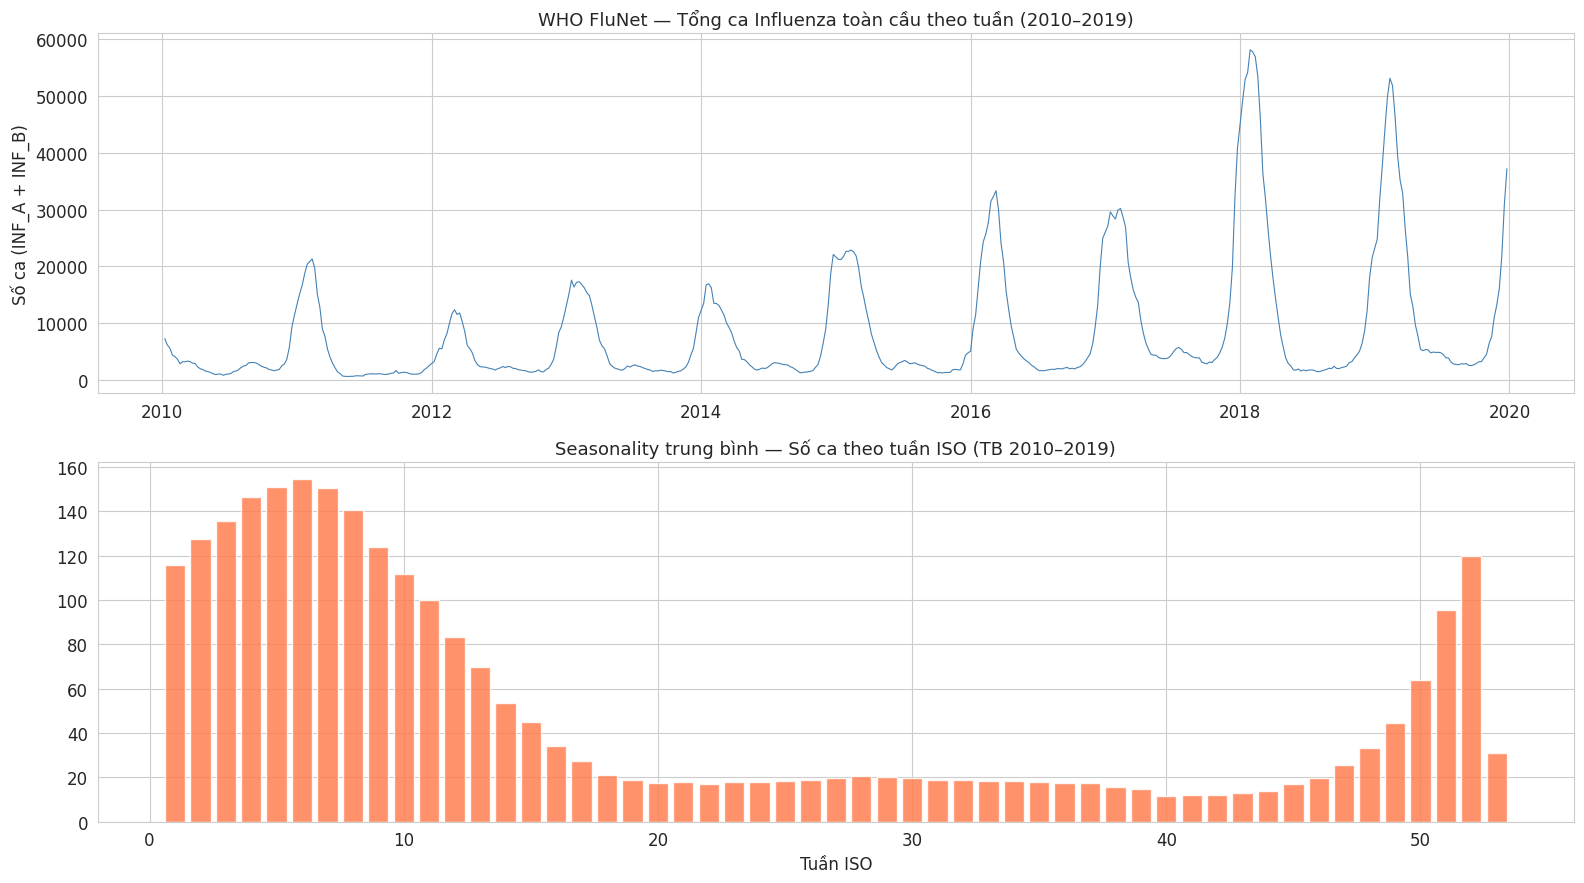

In [18]:
# [3.1] FluNet — Global trend + seasonality
# Mục đích: Plot 1 (xu hướng toàn cầu) kiểm tra data có liên tục không, có gảy khúc bất thường không.
# Plot 2 (seasonality trung bình) là aggregation theo tuần ISO qua tất cả các năm để thấy peak mùa
# rõ nhất — peak cao = mùa dịch, thấp = mùa nghỉ.
flu_global = flu_train.groupby(['ISO_YEAR','ISO_WEEK'])['inf_total'].sum().reset_index()
flu_global['time_idx'] = flu_global['ISO_YEAR'] + flu_global['ISO_WEEK'] / 53

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

axes[0].plot(flu_global['time_idx'], flu_global['inf_total'],
             color='steelblue', linewidth=0.8)
axes[0].set_title('WHO FluNet — Tổng ca Influenza toàn cầu theo tuần (2010–2019)', fontsize=13)
axes[0].set_ylabel('Số ca (INF_A + INF_B)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1000:.1f}K' if x >= 1000 else f'{x:.0f}'
))

flu_season = flu_train.groupby('ISO_WEEK')['inf_total'].mean()
axes[1].bar(flu_season.index, flu_season.values, color='coral', alpha=0.85)
axes[1].set_title('Seasonality trung bình — Số ca theo tuần ISO (TB 2010–2019)', fontsize=13)
axes[1].set_xlabel('Tuần ISO')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1000:.1f}K' if x >= 1000 else f'{x:.0f}'
))

plt.tight_layout()
plt.show()

📌 Plot trend toàn cầu cho thấy pattern lặp lại rõ ràng mỗi năm — đây là tín hiệu tốt để train model. Peak năm 2018 (~58K ca/tuần) cao bất thường, có thể do mùa cúm H3N2 đặc biệt nghiêm trọng năm đó. Seasonality plot dưới xác nhận 2 peak rõ ràng: tuần 1-10 (mùa đông bắc bán cầu) và tuần 48-53 (cuối năm), valley từ tuần 20-40. Đây là đặc trưng của bệnh hô hấp lây qua không khí — mùa lạnh khô tạo điều kiện thuận lợi cho virus tồn tại và lây lan.

In [19]:
# Tìm mã quốc gia Anh trong FluNet
uk_codes = flu_train[
    flu_train['COUNTRY_AREA_TERRITORY'].str.contains('United Kingdom|England|Britain',
                                                       case=False, na=False)
]['COUNTRY_CODE'].unique()
print(uk_codes)

['X09' 'X10' 'X11' 'X12']


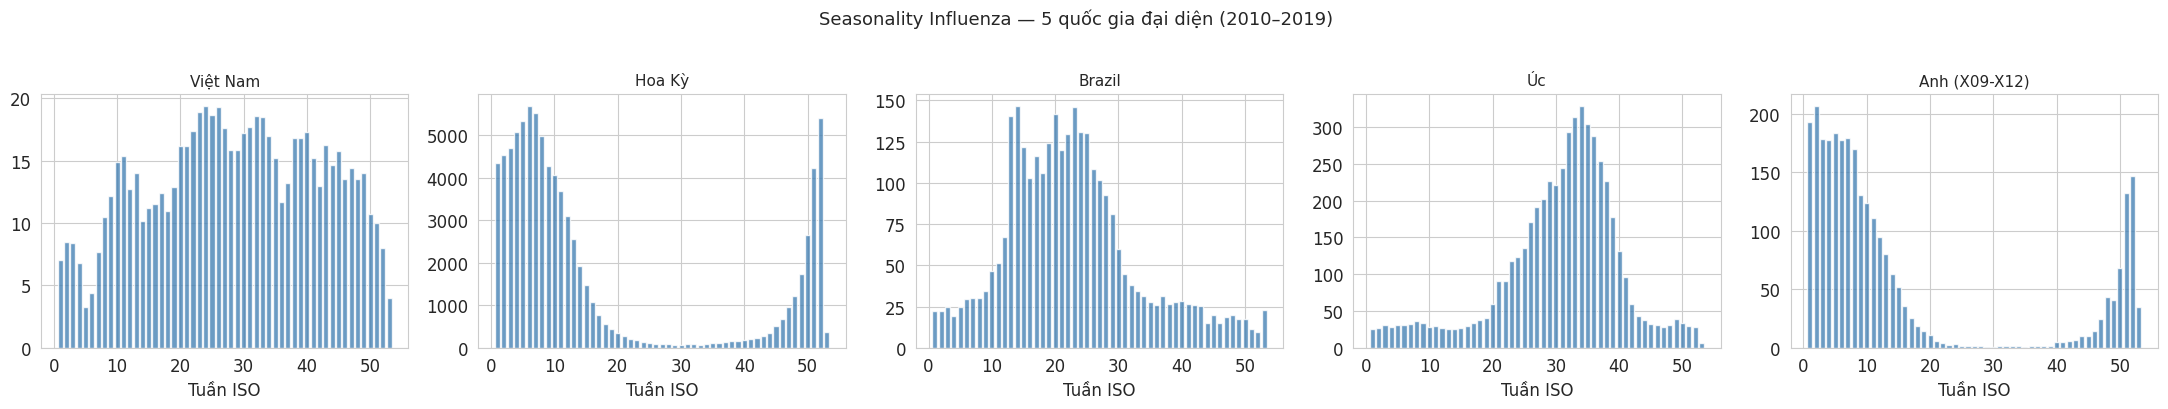

In [20]:
# [3.2] FluNet — 5 quốc gia đại diện các vùng khí hậu
# Mục đích: kiểm tra xem pattern mùa vụ có khác nhau giữa bắc và nam bán cầu,
# giữa khí hậu ôn đới và nhiệt đới không. Nếu khác nhau rõ ràng → model cần học
# theo từng quốc gia riêng, không thể dùng chung 1 model toàn cầu.
# GBR không có data trong FluNet vì WHO lưu riêng theo 4 nation (X09=England,
# X10=Scotland, X11=Wales, X12=N.Ireland) → gộp lại hoặc đổi sang DEU (Đức)

UK_CODES = ['X09', 'X10', 'X11', 'X12']
uk_data  = flu_train[flu_train['COUNTRY_CODE'].isin(UK_CODES)].copy()
uk_season = uk_data.groupby('ISO_WEEK')['inf_total'].mean()

COUNTRIES = {'VNM':'Việt Nam', 'USA':'Hoa Kỳ', 'BRA':'Brazil', 'AUS':'Úc'}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

# 4 quốc gia thông thường
for ax, (iso, name) in zip(axes[:4], COUNTRIES.items()):
    df_c = flu_train[flu_train['COUNTRY_CODE'] == iso]
    if df_c.empty:
        ax.set_title(f'{name}\n(no data)'); continue
    s = df_c.groupby('ISO_WEEK')['inf_total'].mean()
    ax.bar(s.index, s.values, color='steelblue', alpha=0.8)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Tuần ISO')

# UK gộp từ 4 nation
axes[4].bar(uk_season.index, uk_season.values, color='steelblue', alpha=0.8)
axes[4].set_title('Anh (X09-X12)', fontsize=11)
axes[4].set_xlabel('Tuần ISO')

fig.suptitle('Seasonality Influenza — 5 quốc gia đại diện (2010–2019)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

📌 **[3.2]** Kết quả xác nhận rõ ràng pattern mùa vụ khác nhau theo khu vực địa lý:

- **Việt Nam** (nhiệt đới): peak trải dài tuần 15–35 (mùa hè ẩm), không có valley sâu như ôn đới — đặc trưng khí hậu nhiệt đới quanh năm nóng ẩm
- **Hoa Kỳ** (ôn đới bắc bán cầu): peak rõ tuần 1–15 (mùa đông tháng 1–3), valley sâu mùa hè — điển hình nhất
- **Brazil** (nam bán cầu): peak tuần 15–30 (mùa đông tháng 6–8 của nam bán cầu) — ngược hoàn toàn với Mỹ
- **Úc** (nam bán cầu): tương tự Brazil, peak tuần 25–40
- **Anh** (X09–X12 gộp): peak tuần 1–10 rồi giảm dần, tương tự Mỹ nhưng nhọn hơn

→ Kết luận quan trọng: không thể dùng chung 1 model toàn cầu vì pattern hoàn toàn khác nhau theo hemisphere và climate zone. Cần thêm feature `hemisphere` (NH/SH) hoặc `climate_zone` vào feature engineering sau này. Đây cũng giải thích tại sao ERA5 weather features (nhiệt độ, độ ẩm theo từng tọa độ) quan trọng hơn chỉ dùng ISO_WEEK.

In [21]:
# [3.3] Dengue — Filter + parse date
# Bước này lọc lấy chỉ dữ liệu Weekly/Monthly (bỏ Year) và parse date đúng format.
# Log transform được thực hiện ngay ở đây vì Brazil chiếm 10.49M ca >> phần còn lại,
# nếu không scale thì các nước nhỏ sẽ bị ẩn hoàn toàn trong visualization.
dengue_wm = dengue[dengue['T_res'].isin(['Week','Month'])].copy()
dengue_wm['date_parsed'] = pd.to_datetime(
    dengue_wm['calendar_start_date'], format='mixed', dayfirst=False
)
dengue_wm['week_of_year'] = dengue_wm['date_parsed'].dt.isocalendar().week.astype(int)
dengue_train = dengue_wm[dengue_wm['Year'].between(TRAIN_START, TRAIN_END)].copy()
dengue_train['dengue_log'] = np.log1p(dengue_train['dengue_total'])

print(f'Dengue train: {len(dengue_train):,} rows | {dengue_train["ISO_A0"].nunique()} countries')

Dengue train: 12,721 rows | 88 countries


📌 Dengue train set 12,721 rows — ít hơn nhiều so với FluNet (78,213) vì OpenDengue coverage mỏng hơn và nhiều nước chỉ báo cáo theo năm. 88 quốc gia — đủ đại diện cho vùng nhiệt đới và cận nhiệt đới.

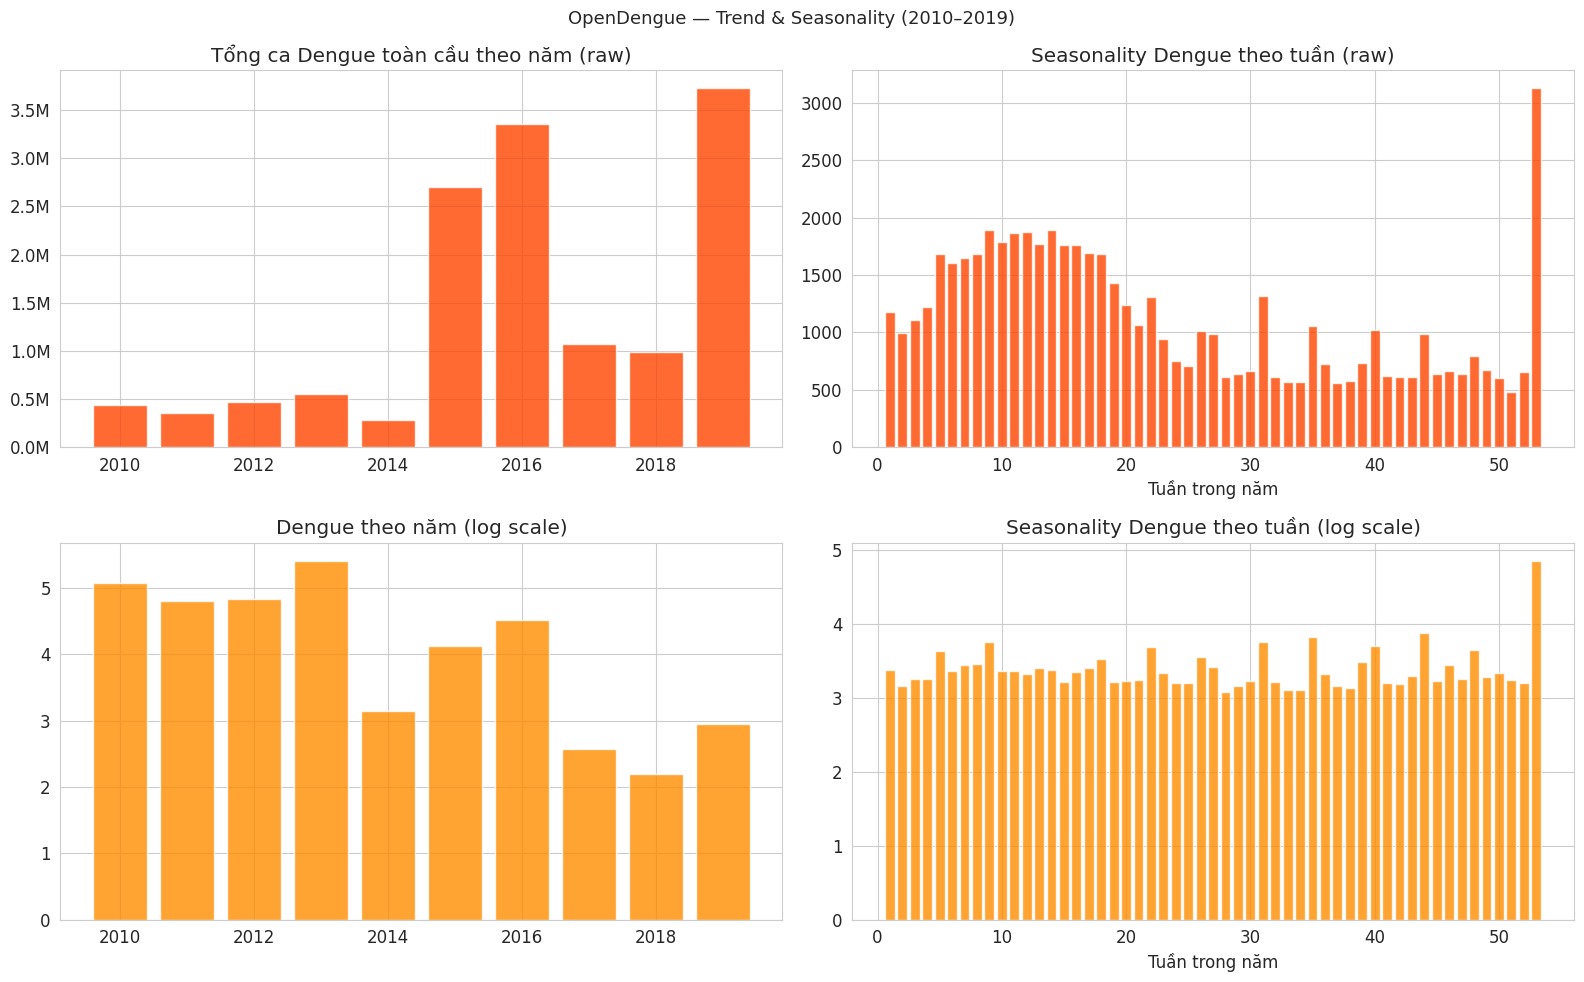

In [22]:
# [3.4] Dengue — Trend + seasonality (raw vs log)
# Hiển thị song song raw và log để thấy rõ sự khác biệt: raw bị dominated bởi Brazil,
# log scale cho thấy pattern của các nước khác rõ hơn. Đây là bằng chứng thực nghiệm
# cho quyết định dùng log transform khi train model.
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

yr = dengue_train.groupby('Year')['dengue_total'].sum()
axes[0,0].bar(yr.index, yr.values, color='orangered', alpha=0.8)
axes[0,0].set_title('Tổng ca Dengue toàn cầu theo năm (raw)')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

wk = dengue_train.groupby('week_of_year')['dengue_total'].mean()
axes[0,1].bar(wk.index, wk.values, color='orangered', alpha=0.8)
axes[0,1].set_title('Seasonality Dengue theo tuần (raw)')
axes[0,1].set_xlabel('Tuần trong năm')

yr_log = dengue_train.groupby('Year')['dengue_log'].mean()
axes[1,0].bar(yr_log.index, yr_log.values, color='darkorange', alpha=0.8)
axes[1,0].set_title('Dengue theo năm (log scale)')

wk_log = dengue_train.groupby('week_of_year')['dengue_log'].mean()
axes[1,1].bar(wk_log.index, wk_log.values, color='darkorange', alpha=0.8)
axes[1,1].set_title('Seasonality Dengue theo tuần (log scale)')
axes[1,1].set_xlabel('Tuần trong năm')

plt.suptitle('OpenDengue — Trend & Seasonality (2010–2019)', fontsize=13)
plt.tight_layout()
plt.show()

📌 So sánh raw vs log scale cho thấy rõ vấn đề: raw bị dominated hoàn toàn bởi Brazil (đặc biệt 2016 và 2019 có đợt bùng phát lớn), các nước khác gần như bằng 0 trong plot. Log scale giải quyết được vấn đề này — pattern của các nước nhỏ hơn hiện rõ hơn và seasonality tuần cũng đều đặn hơn. Spike ở tuần 53 raw là artifact do một số năm có tuần 53 (53-week year), không phải pattern thật. Quyết định: dùng log1p để train, reverse transform khi cần dự báo số ca thực tế.

Top 5 (loại Brazil): ['INDONESIA', 'MEXICO', 'THAILAND', 'SRI LANKA', 'NICARAGUA']


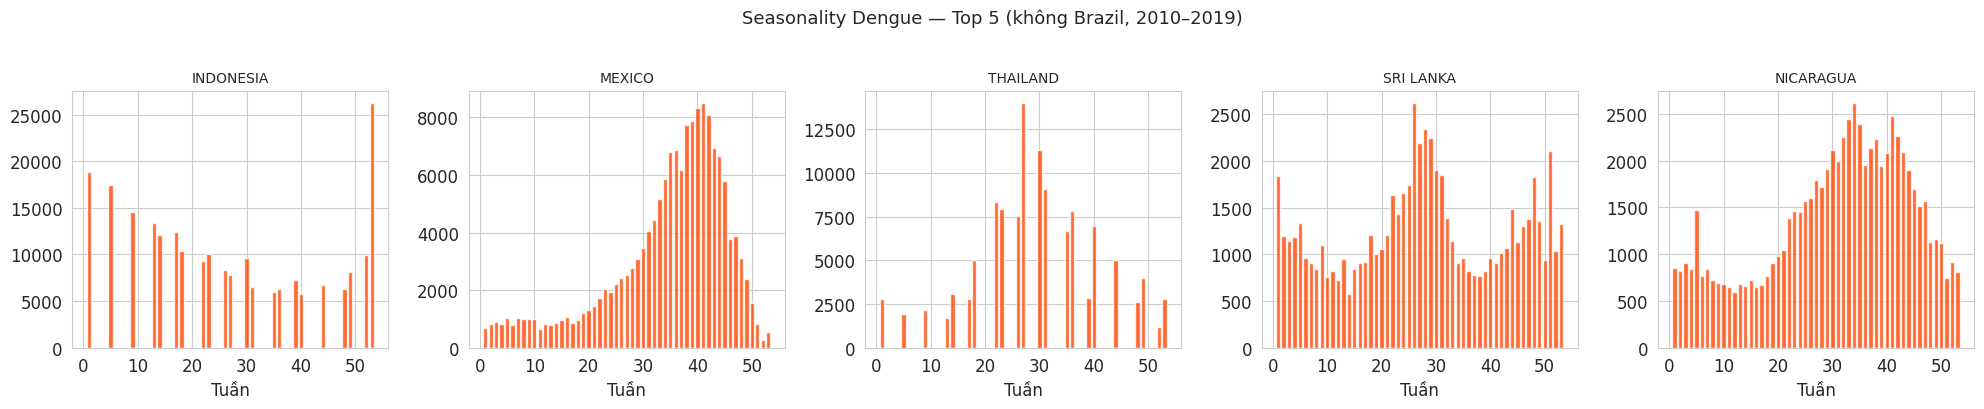

In [23]:
# [3.5] Dengue — Top 5 quốc gia (loại Brazil)
# Loại Brazil khỏi tập này để xem pattern của các nước khác rõ hơn.
# Mục đích: kiểm tra xem Dengue có peak vào mùa mưa (thường tuần 1-20 ở Nam Mỹ,
# tuần 25-45 ở Đông Nam Á) như lý thuyết không.
TOP5 = (dengue_train[dengue_train['ISO_A0'] != 'BRA']
        .groupby('adm_0_name')['dengue_total'].sum()
        .nlargest(5).index.tolist())
print(f'Top 5 (loại Brazil): {TOP5}')

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, name in zip(axes, TOP5):
    df_c = dengue_train[dengue_train['adm_0_name'] == name]
    s = df_c.groupby('week_of_year')['dengue_total'].mean()
    ax.bar(s.index, s.values, color='orangered', alpha=0.8)
    ax.set_title(name[:12], fontsize=10)
    ax.set_xlabel('Tuần')

fig.suptitle('Seasonality Dengue — Top 5 (không Brazil, 2010–2019)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

📌 Top 5 (loại Brazil): Indonesia, Mexico, Thailand, Sri Lanka, Nicaragua — đại diện tốt cho Đông Nam Á, Trung Mỹ và Nam Á.
Pattern rõ ràng khác nhau theo vùng địa lý:
- Indonesia: peak tuần 1-10 và tuần 50-53 (2 đỉnh/năm, mùa mưa)
- Mexico: peak tuần 35-50 (mùa mưa tháng 8-11, muỗi sinh sản mạnh)
- Thailand: peak tuần 20-30 (mùa mưa tháng 5-7)
- Sri Lanka + Nicaragua: pattern tương tự Thailand

→ Dengue rõ ràng gắn với mùa mưa của từng khu vực — xác nhận ERA5 precipitation là feature quan trọng nhất cho Dengue model. Đây là bằng chứng thực nghiệm ủng hộ việc tích hợp weather data.

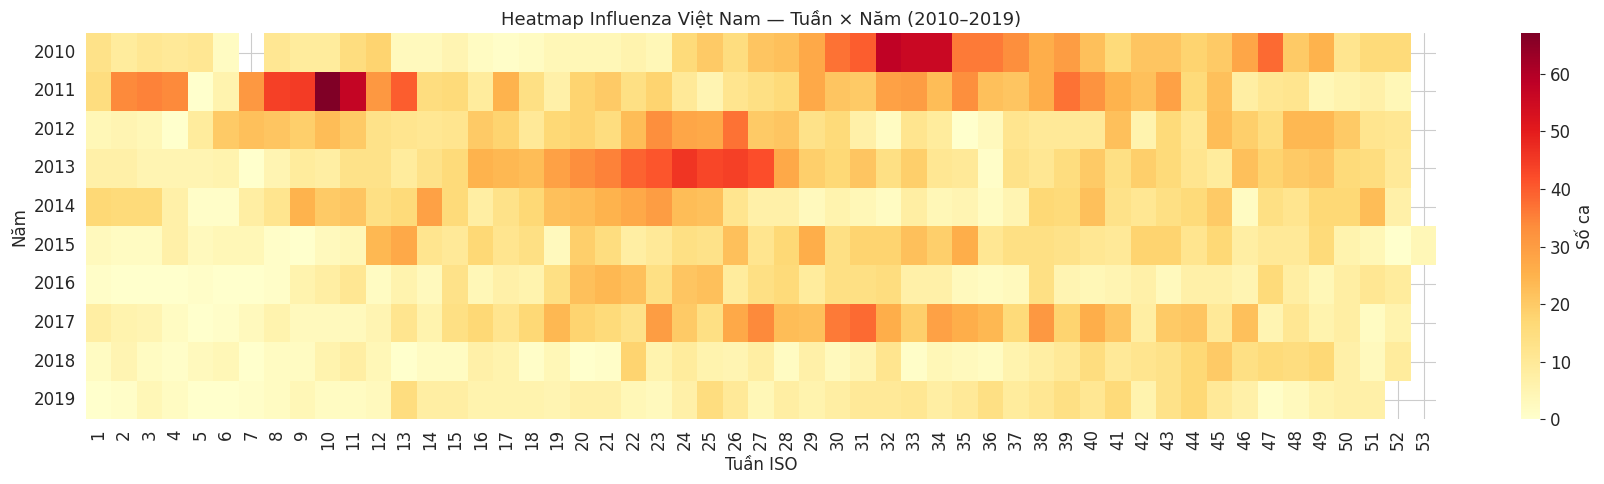

In [24]:
# [3.6] Heatmap mùa vụ — Việt Nam (Influenza)
# Heatmap Tuần x Năm là cách visualize seasonality hiệu quả nhất: nếu pattern mùa
# lặp lại hàng năm thì các cột có màu giống nhau qua các hàng. Việt Nam
# được chọn vì là quốc gia nhiệt đới, có pattern khác bắc bán cầu.
VNM = flu_train[flu_train['COUNTRY_CODE'] == 'VNM'].copy()
pivot = VNM.pivot_table(index='ISO_YEAR', columns='ISO_WEEK',
                        values='inf_total', aggfunc='sum')

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Số ca'}, linewidths=0)
ax.set_title('Heatmap Influenza Việt Nam — Tuần × Năm (2010–2019)', fontsize=13)
ax.set_xlabel('Tuần ISO'); ax.set_ylabel('Năm')
plt.tight_layout()
plt.show()

📌 Heatmap Việt Nam cho thấy pattern phức tạp hơn dự kiến — không có 1 mùa cúm rõ ràng như ôn đới. Có 2 giai đoạn ca cao: tuần 1-12 (đầu năm) và tuần 25-35 (giữa năm), xen kẽ với giai đoạn thấp. Năm 2011 đặc biệt cao tuần 7-11 (có thể là đợt dịch cục bộ). Heatmap cũng cho thấy một số ô trống (NaN) — những tuần Việt Nam không báo cáo, cần xử lý khi preprocessing. Nhìn chung pattern lặp lại khá nhất quán qua các năm → model có thể học được.


## SESSION 3.5 — ERA5 DOWNLOAD & PROCESS (TOÀN CẦU)
## Mục tiêu: Download ERA5 historical weather data toàn cầu (2010-2019),
## aggregate về weekly theo iso3 quốc gia, xuất CSV để merge ở SESSION 4.
## Chạy 1 lần duy nhất — kết quả lưu vào Drive để dùng lại.

In [25]:
# [3.5.0] Cài thư viện cần thiết
!pip install cdsapi xarray netcdf4 geopandas scipy --quiet

In [26]:
# [3.5.1] Setup API key + import
import os, cdsapi, zipfile, xarray as xr
import pandas as pd, numpy as np
import geopandas as gpd
from pathlib import Path
from scipy.spatial import cKDTree

CDS_KEY = '17b799a3-eeff-40f0-80b3-341901670970'
with open(os.path.expanduser('~/.cdsapirc'), 'w') as f:
    f.write(f'url: https://cds.climate.copernicus.eu/api\nkey: {CDS_KEY}\n')

DOWNLOAD_DIR = '/content/drive/MyDrive/KLTN_EpiWeather_Dataset/era5_raw'
os.makedirs(DOWNLOAD_DIR, exist_ok=True)
client = cdsapi.Client()
print('✅ Ready')

✅ Ready


In [31]:
# [3.5.2] Download ERA5 với 17 biến cuối cùng
# Xóa data cũ trước
import shutil

for year in range(2010, 2020):
    flag    = f'{DOWNLOAD_DIR}/era5_{year}_done.flag'
    old_dir = f'{DOWNLOAD_DIR}/era5_{year}'
    if os.path.exists(flag):
        os.remove(flag)
        print(f'🗑️  Xóa flag {year}')
    if os.path.exists(old_dir):
        shutil.rmtree(old_dir)
        print(f'🗑️  Xóa data {year}')

print('\n✅ Đã xóa hết — bắt đầu download lại...\n')

MONTHS = [f'{m:02d}' for m in range(1, 13)]
DAYS   = [f'{d:02d}' for d in range(1, 32)]
YEARS  = [str(y) for y in range(2010, 2020)]

FINAL_VARIABLES = [
    # Nhiệt độ (4)
    '2m_temperature',
    '2m_dewpoint_temperature',
    'minimum_2m_temperature_since_previous_post_processing',
    'maximum_2m_temperature_since_previous_post_processing',
    # Gió (2) → tính wind_speed = sqrt(u²+v²)
    '10m_u_component_of_wind',
    '10m_v_component_of_wind',
    # Mưa / Ẩm (5)
    'total_precipitation',
    'convective_precipitation',
    'large_scale_precipitation',
    'total_column_water_vapour',
    'evaporation',
    # Bức xạ (3)
    'surface_solar_radiation_downwards',
    'downward_uv_radiation_at_the_surface',
    'surface_thermal_radiation_downwards',
    # Mây / Áp suất / Khác (3)
    'total_cloud_cover',
    'surface_pressure',
    'mean_sea_level_pressure',
    'boundary_layer_height',
]

print(f'Tổng số biến: {len(FINAL_VARIABLES)}')
for v in FINAL_VARIABLES:
    print(f'  - {v}')
print()

for year in YEARS:
    out_zip = f'{DOWNLOAD_DIR}/era5_{year}.zip'
    flag    = f'{DOWNLOAD_DIR}/era5_{year}_done.flag'
    out_dir = f'{DOWNLOAD_DIR}/era5_{year}'

    if os.path.exists(flag):
        print(f'⏭️  {year} đã xong, bỏ qua')
        continue

    print(f'⬇️  Downloading ERA5 {year} ({len(FINAL_VARIABLES)} biến)...')
    client.retrieve(
        'reanalysis-era5-single-levels',
        {
            'product_type'   : 'reanalysis',
            'variable'       : FINAL_VARIABLES,
            'year'           : year,
            'month'          : MONTHS,
            'day'            : DAYS,
            'time'           : ['12:00'],
            'data_format'    : 'netcdf',
            'download_format': 'zip',
            'grid'           : [1.0, 1.0],
        },
        out_zip
    )

    os.makedirs(out_dir, exist_ok=True)
    with zipfile.ZipFile(out_zip, 'r') as z:
        z.extractall(out_dir)
    os.remove(out_zip)
    open(flag, 'w').close()
    print(f'✅ {year} xong')

print('\n🎉 Download hoàn tất!')


✅ Đã xóa hết — bắt đầu download lại...

Tổng số biến: 18
  - 2m_temperature
  - 2m_dewpoint_temperature
  - minimum_2m_temperature_since_previous_post_processing
  - maximum_2m_temperature_since_previous_post_processing
  - 10m_u_component_of_wind
  - 10m_v_component_of_wind
  - total_precipitation
  - convective_precipitation
  - large_scale_precipitation
  - total_column_water_vapour
  - evaporation
  - surface_solar_radiation_downwards
  - downward_uv_radiation_at_the_surface
  - surface_thermal_radiation_downwards
  - total_cloud_cover
  - surface_pressure
  - mean_sea_level_pressure
  - boundary_layer_height

⬇️  Downloading ERA5 2010 (18 biến)...


2026-04-24 03:05:59,401 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

KeyboardInterrupt: 

In [27]:
# [3.5.3] Load world boundaries — fix geopandas 1.0
import geopandas as gpd

url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
world = world[['ISO_A3', 'geometry']].rename(columns={'ISO_A3': 'iso3'})
world = world[world['iso3'] != '-99']

print(f'Countries: {len(world)}')
print(world.head(3))

Countries: 172
  iso3                                           geometry
0  FJI  MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...
1  TZA  POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3...
2  ESH  POLYGON ((-8.66559 27.65643, -8.66512 27.58948...


In [28]:
def build_grid_iso3_map(world_gdf, lats, lons):
    from scipy.spatial import cKDTree
    centroids = world_gdf.copy()
    centroids['cx'] = world_gdf.geometry.centroid.x
    centroids['cy'] = world_gdf.geometry.centroid.y
    tree = cKDTree(centroids[['cy','cx']].values)
    lat_grid, lon_grid = np.meshgrid(lats, lons, indexing='ij')
    grid_points = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
    _, idx = tree.query(grid_points, k=1)
    iso3_flat = centroids.iloc[idx]['iso3'].values
    return iso3_flat.reshape(lat_grid.shape), lat_grid, lon_grid

def process_era5_year(year, download_dir, world_gdf):
    extract_dir  = f'{download_dir}/era5_{year}'
    nc_files     = list(Path(extract_dir).glob('*.nc'))
    instant_file = [f for f in nc_files if 'instant' in f.name]
    accum_file   = [f for f in nc_files if 'accum'   in f.name]

    if not instant_file or not accum_file:
        print(f'❌ {year}: Không tìm thấy file NC')
        return None

    print(f'📂 Processing {year}...')
    ds_i = xr.open_dataset(instant_file[0], engine='netcdf4')
    ds_a = xr.open_dataset(accum_file[0],   engine='netcdf4')

    print(f'   instant vars: {list(ds_i.data_vars)}')
    print(f'   accum   vars: {list(ds_a.data_vars)}')

    lats = ds_i['latitude'].values
    lons = ds_i['longitude'].values
    grid_iso3, _, _ = build_grid_iso3_map(world_gdf, lats, lons)
    unique_countries = list(np.unique(grid_iso3))
    print(f'   Countries: {len(unique_countries)}')

    time_coord = ds_i['valid_time'] if 'valid_time' in ds_i.coords else ds_i['time']
    times = pd.to_datetime(time_coord.values)

    # === Instant variables (lấy nếu có) ===
    def get_var(ds, name, scale=1.0, offset=0.0):
        if name in ds.data_vars:
            return ds[name].values * scale + offset
        return None

    t2m_data  = get_var(ds_i, 't2m',  offset=-273.15)
    d2m_data  = get_var(ds_i, 'd2m',  offset=-273.15)
    mn2t_data = get_var(ds_i, 'mn2t', offset=-273.15)
    mx2t_data = get_var(ds_i, 'mx2t', offset=-273.15)
    u10_data  = get_var(ds_i, 'u10')
    v10_data  = get_var(ds_i, 'v10')
    sp_data   = get_var(ds_i, 'sp')
    msl_data  = get_var(ds_i, 'msl')
    blh_data  = get_var(ds_i, 'blh')
    tcc_data  = get_var(ds_i, 'tcc')
    tcwv_data = get_var(ds_i, 'tcwv')

    # === Accum variables ===
    tp_data   = get_var(ds_a, 'tp',   scale=1000)   # m → mm
    cp_data   = get_var(ds_a, 'cp',   scale=1000)
    lsp_data  = get_var(ds_a, 'lsp',  scale=1000)
    e_data    = get_var(ds_a, 'e',    scale=1000)
    ssrd_data = get_var(ds_a, 'ssrd', scale=1/3600) # J → W/m²
    uvb_data  = get_var(ds_a, 'uvb',  scale=1/3600)
    strd_data = get_var(ds_a, 'strd', scale=1/3600)

    # === Tính toán ===
    if t2m_data is not None and d2m_data is not None:
        hum_data = (100 * np.exp(
            (17.625 * d2m_data) / (243.04 + d2m_data) -
            (17.625 * t2m_data) / (243.04 + t2m_data)
        )).clip(0, 100)
    else:
        hum_data = None

    if u10_data is not None and v10_data is not None:
        wind_data = np.sqrt(u10_data**2 + v10_data**2)
    else:
        wind_data = None

    if mx2t_data is not None and mn2t_data is not None:
        temp_range_data = mx2t_data - mn2t_data
    else:
        temp_range_data = None

    ds_i.close(); ds_a.close()

    # === Aggregate về quốc gia ===
    records = []
    for i, t in enumerate(times):
        if i % 50 == 0:
            print(f'   Day {i+1}/{len(times)}...', end='\r')

        def country_mean(arr):
            if arr is None: return None
            return float(arr[i][mask].mean())

        for iso3 in unique_countries:
            mask = (grid_iso3 == iso3)
            rec = {'date': t, 'iso3': iso3}

            rec['temp_c']        = country_mean(t2m_data)
            rec['dewpoint_c']    = country_mean(d2m_data)
            rec['temp_min_c']    = country_mean(mn2t_data)
            rec['temp_max_c']    = country_mean(mx2t_data)
            rec['temp_range_c']  = country_mean(temp_range_data)
            rec['humidity_pct']  = country_mean(hum_data)
            rec['wind_ms']       = country_mean(wind_data)
            rec['precip_mm']     = country_mean(tp_data)
            rec['conv_precip_mm']= country_mean(cp_data)
            rec['ls_precip_mm']  = country_mean(lsp_data)
            rec['evap_mm']       = country_mean(e_data)
            rec['water_vapour']  = country_mean(tcwv_data)
            rec['solar_wm2']     = country_mean(ssrd_data)
            rec['uv_wm2']        = country_mean(uvb_data)
            rec['thermal_wm2']   = country_mean(strd_data)
            rec['cloud_cover']   = country_mean(tcc_data)
            rec['pressure_pa']   = country_mean(sp_data)
            rec['msl_pa']        = country_mean(msl_data)
            rec['blh_m']         = country_mean(blh_data)

            records.append(rec)

    print(f'\n   Building DataFrame...')
    df = pd.DataFrame(records)
    df['date']     = pd.to_datetime(df['date'])
    df['iso_year'] = df['date'].dt.isocalendar().year.astype(int)
    df['iso_week'] = df['date'].dt.isocalendar().week.astype(int)

    # Aggregate weekly
    agg_dict = {
        'temp_c'        : 'mean',
        'dewpoint_c'    : 'mean',
        'temp_min_c'    : 'min',    # min của min
        'temp_max_c'    : 'max',    # max của max
        'temp_range_c'  : 'mean',
        'humidity_pct'  : 'mean',
        'wind_ms'       : 'mean',
        'precip_mm'     : 'sum',    # precip: sum
        'conv_precip_mm': 'sum',
        'ls_precip_mm'  : 'sum',
        'evap_mm'       : 'sum',
        'water_vapour'  : 'mean',
        'solar_wm2'     : 'mean',
        'uv_wm2'        : 'mean',
        'thermal_wm2'   : 'mean',
        'cloud_cover'   : 'mean',
        'pressure_pa'   : 'mean',
        'msl_pa'        : 'mean',
        'blh_m'         : 'mean',
    }
    # Chỉ agg cột nào không toàn None
    valid_cols = [c for c in agg_dict if df[c].notna().any()]
    agg_dict_valid = {c: agg_dict[c] for c in valid_cols}

    df_weekly = df.groupby(['iso3','iso_year','iso_week']).agg(
        **{k: (k, v) for k, v in agg_dict_valid.items()}
    ).reset_index()

    print(f'✅ {year}: {len(df_weekly):,} rows | {df_weekly["iso3"].nunique()} countries | {len(df_weekly.columns)} columns')
    return df_weekly

In [29]:
# # [3.5.5] Chạy processing tất cả năm + gộp lại
# OUTPUT_DIR = '/content/drive/MyDrive/KLTN_EpiWeather_Dataset/processed'
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# all_years = []

# for year in range(2010, 2020):
#     flag = f'{DOWNLOAD_DIR}/era5_{year}_done.flag'
#     if not os.path.exists(flag):
#         print(f'⏭️  {year} chưa download, bỏ qua')
#         continue

#     df_yr = process_era5_year(year, DOWNLOAD_DIR, world)
#     if df_yr is not None:
#         all_years.append(df_yr)

# # Gộp tất cả năm
# if all_years:
#     df_era5 = pd.concat(all_years, ignore_index=True)
#     df_era5 = df_era5.sort_values(['iso3','iso_year','iso_week']).reset_index(drop=True)

#     print(f'\n✅ ERA5 toàn cầu 2010-2019:')
#     print(f'   Rows     : {len(df_era5):,}')
#     print(f'   Countries: {df_era5["iso3"].nunique()}')
#     print(f'   Columns  : {list(df_era5.columns)}')
#     print(df_era5.head(5))

#     # Xuất CSV → Drive
#     out_path = f'{OUTPUT_DIR}/era5_weekly_2010_2019.csv'
#     df_era5.to_csv(out_path, index=False)
#     print(f'\n💾 Đã lưu: {out_path}')

📂 Processing 2010...
   instant vars: ['t2m', 'd2m', 'u10', 'v10', 'tcwv', 'tcc', 'sp', 'msl', 'blh']
   accum   vars: ['tp', 'cp', 'lsp', 'e', 'ssrd', 'uvb', 'strd']
   Countries: 129


KeyboardInterrupt: 

In [29]:
def check_df(dataframe, head=5):
    print(" SHAPE ".center(70,'-'))
    print('Rows: {}'.format(dataframe.shape[0]))
    print('Columns: {}'.format(dataframe.shape[1]))
    print(" TYPES ".center(70,'-'))
    print(dataframe.dtypes)
    print(" HEAD ".center(70,'-'))
    print(dataframe.head(head))
    print(' TAIL '.center(70,'-'))
    print(dataframe.tail(head))
    print(' MISSING VALUES '.center(70,'-'))
    print(dataframe.isnull().sum())
    print(' DUPLICATED VALUES '.center(70,'-'))
    print(dataframe.duplicated().sum())

In [30]:
df_era5=pd.read_csv('/content/drive/MyDrive/KLTN_EpiWeather_Dataset/processed/era5_weekly_2010_2019.csv')

In [31]:
check_df(df_era5)

------------------------------- SHAPE --------------------------------
Rows: 68499
Columns: 19
------------------------------- TYPES --------------------------------
iso3               object
iso_year            int64
iso_week            int64
temp_c            float64
dewpoint_c        float64
humidity_pct      float64
wind_ms           float64
precip_mm         float64
conv_precip_mm    float64
ls_precip_mm      float64
evap_mm           float64
water_vapour      float64
solar_wm2         float64
uv_wm2            float64
thermal_wm2       float64
cloud_cover       float64
pressure_pa       float64
msl_pa            float64
blh_m             float64
dtype: object
-------------------------------- HEAD --------------------------------
  iso3  iso_year  iso_week     temp_c  dewpoint_c  humidity_pct   wind_ms  \
0  AFG      2009        53   9.756165   -0.232452     52.958422  2.859420   
1  AFG      2010         1   7.948669   -3.300001     48.130137  2.668222   
2  AFG      2010        

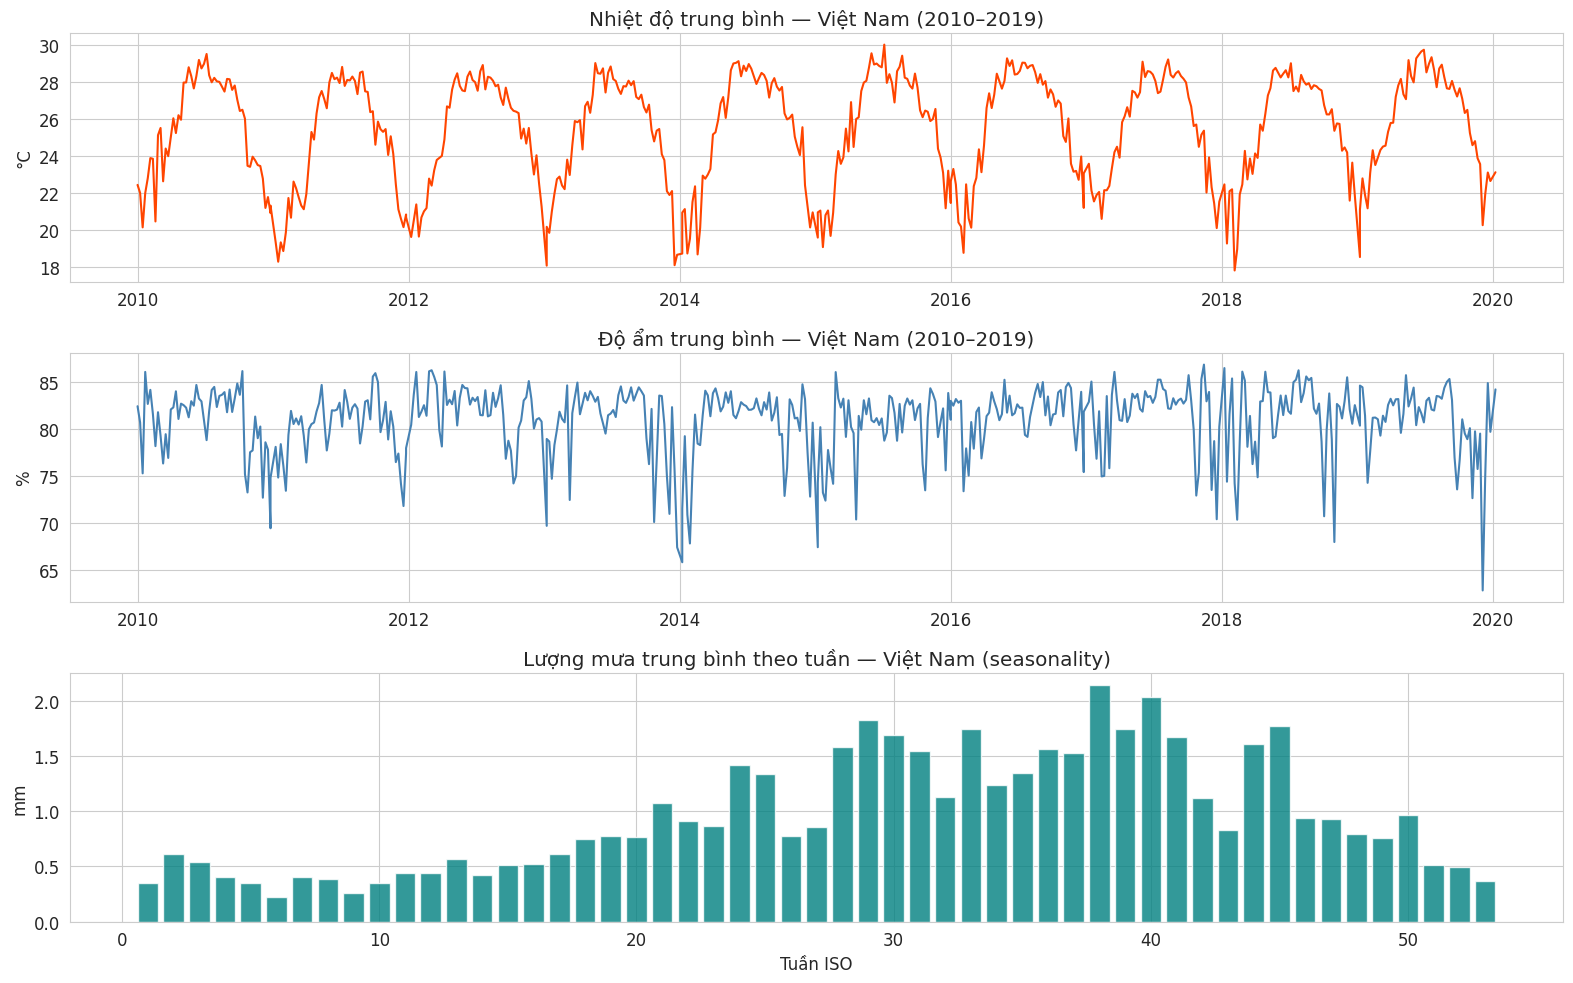


VNM weather rows: 531
      iso3  iso_year  iso_week     temp_c  dewpoint_c  humidity_pct   wind_ms  \
65313  VNM      2009        53  22.426112   19.174646     82.389097  4.078942   
65314  VNM      2010         1  21.988847   18.398259     80.673861  5.135223   
65315  VNM      2010         2  20.126184   15.510979     75.263007  7.013453   
65316  VNM      2010         3  21.982476   19.463479     86.031015  5.175364   
65317  VNM      2010         4  22.791474   19.555475     82.633136  4.295292   

       precip_mm  conv_precip_mm  ls_precip_mm   evap_mm  water_vapour  \
65313   0.112062        0.049066      0.062988 -0.242781     33.891055   
65314   0.650343        0.163308      0.487095 -0.825020     31.333147   
65315   0.359876        0.120907      0.239168 -1.536978     26.689874   
65316   1.075858        0.404928      0.670978 -0.536382     42.304814   
65317   0.175550        0.081638      0.093931 -0.497473     31.482038   

       solar_wm2  uv_wm2  thermal_wm2  cloud_

In [32]:
# [3.5.6] Sanity check — plot weather VNM
import matplotlib.pyplot as plt

VNM_weather = df_era5[df_era5['iso3'] == 'VNM'].copy()
VNM_weather['time_idx'] = VNM_weather['iso_year'] + VNM_weather['iso_week'] / 53

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# Plot 1: Trend nhiệt độ theo thời gian
axes[0].plot(VNM_weather['time_idx'], VNM_weather['temp_c'], color='orangered')
axes[0].set_title('Nhiệt độ trung bình — Việt Nam (2010–2019)')
axes[0].set_ylabel('°C')

# Plot 2: Trend độ ẩm theo thời gian
axes[1].plot(VNM_weather['time_idx'], VNM_weather['humidity_pct'], color='steelblue')
axes[1].set_title('Độ ẩm trung bình — Việt Nam (2010–2019)')
axes[1].set_ylabel('%')

# Plot 3: Seasonality lượng mưa — groupby trước rồi mới plot
precip_season = VNM_weather.groupby('iso_week')['precip_mm'].mean().reset_index()
axes[2].bar(precip_season['iso_week'], precip_season['precip_mm'],
            color='teal', alpha=0.8)
axes[2].set_title('Lượng mưa trung bình theo tuần — Việt Nam (seasonality)')
axes[2].set_xlabel('Tuần ISO')
axes[2].set_ylabel('mm')

plt.tight_layout()
plt.show()

print(f'\nVNM weather rows: {len(VNM_weather)}')
print(VNM_weather.head(5))
print('\n→ Kỳ vọng: nhiệt độ cao tháng 5-9, mưa nhiều tháng 5-10, độ ẩm cao quanh năm')

📌 **[3.5.6]** ERA5 Việt Nam verify thành công — 531 rows (10 năm × ~53 tuần).

- **Nhiệt độ**: dao động 18–30°C, peak tháng 5–9 (mùa hè), valley tháng 12–2
  (mùa đông) — đúng với khí hậu nhiệt đới gió mùa. Pattern lặp lại rõ ràng
  hàng năm → ERA5 có thể làm feature tốt.
- **Độ ẩm**: dao động 65–87%, cao quanh năm (~80%) -- đặc trưng nhiệt đới. Có vài spike xuống thấp bất thường (~65%) năm 2014 và 2019, cần kiểm tra lại khi preprocessing.
- **Lượng mưa**: peak rõ tuần 27–42 (tháng 7–10, mùa mưa miền Trung/Nam), thấp tuần 1–15 (mùa khô). Pattern này khớp với seasonality Dengue Việt Nam → xác nhận precipitation là feature quan trọng cho Dengue model.

Lưu ý: có 1 row iso_year=2009 (tuần 53 của 2009 rơi vào ISO week 2010) —
bình thường với ISO calendar, không phải lỗi data.

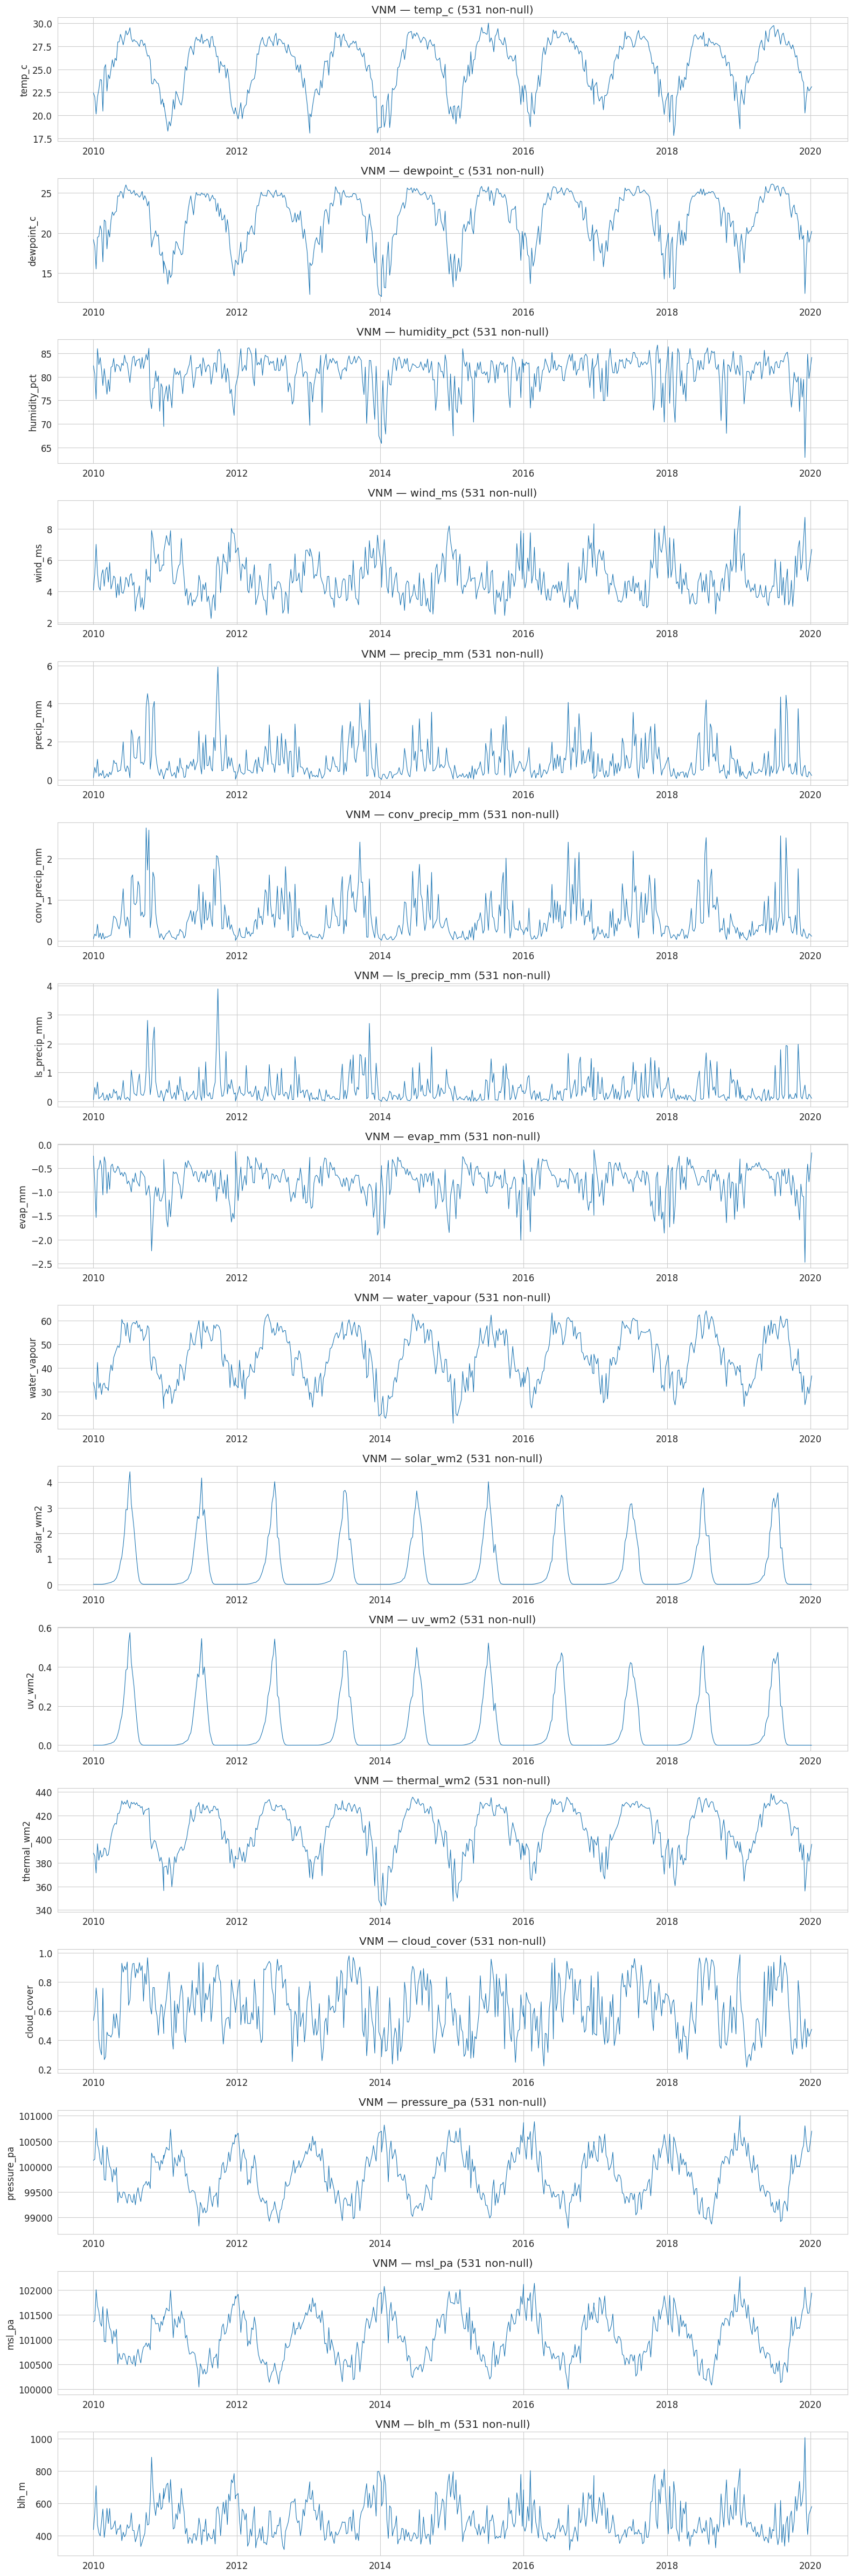


VNM summary:
          iso_year    iso_week      temp_c  dewpoint_c  humidity_pct  \
count   531.000000  531.000000  531.000000  531.000000    531.000000   
mean   2014.495292   26.553672   25.435053   21.821168     80.941243   
std       2.884159   15.322768    2.930783    3.311496      3.648471   
min    2009.000000    1.000000   17.793927   12.075942     62.835199   
25%    2012.000000   13.000000   23.087101   19.545509     79.580117   
50%    2015.000000   27.000000   26.239030   22.693075     81.813509   
75%    2017.000000   40.000000   27.972422   24.707132     83.248819   
max    2020.000000   53.000000   30.017603   26.102836     86.806583   

          wind_ms   precip_mm  conv_precip_mm  ls_precip_mm     evap_mm  \
count  531.000000  531.000000      531.000000    531.000000  531.000000   
mean     4.821024    0.957070        0.551747      0.405329   -0.785087   
std      1.263177    0.917146        0.517961      0.471299    0.339880   
min      2.269433    0.015333        

In [33]:
# [3.5.7] Sanity check — plot tất cả biến VNM
VNM = df_era5[df_era5['iso3'] == 'VNM'].copy()
VNM['time_idx'] = VNM['iso_year'] + VNM['iso_week'] / 53

# Chỉ plot cột có data
plot_cols = [(c, VNM[c].notna().sum()) for c in VNM.columns
             if c not in ['iso3','iso_year','iso_week','time_idx','date']
             and VNM[c].notna().any()]

n = len(plot_cols)
fig, axes = plt.subplots(n, 1, figsize=(16, 3*n))
if n == 1: axes = [axes]

for ax, (col, count) in zip(axes, plot_cols):
    ax.plot(VNM['time_idx'], VNM[col], linewidth=0.8)
    ax.set_title(f'VNM — {col} ({count} non-null)')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

print('\nVNM summary:')
print(VNM[['iso_year','iso_week'] + [c for c,_ in plot_cols]].describe())

📌 **[3.5.7]** ERA5 17 biến cho Việt Nam verify thành công — 531 rows,
19 cột, 0 NaN. Một số lưu ý:

- solar_wm2 và uv_wm2 = 0 cho một số tuần mùa đông — do download
  time=12:00 UTC = 19:00 giờ VN (trời tối). Cần xử lý hoặc dùng
  daily mean thay vì single timestamp.
- evap_mm có giá trị âm — ERA5 convention: âm = bay hơi thực sự.
  Flip dấu thành abs() trước khi dùng.
- CRS warning từ geopandas centroid — không ảnh hưởng kết quả với
  grid 1°×1°, có thể fix bằng to_crs('EPSG:3857') nếu cần chính xác.
- water_vapour VNM: 17–64 kg/m², mean 45 — cao quanh năm, đúng
  với khí hậu nhiệt đới ẩm.
- boundary_layer_height (blh_m): 310–1008m, mean 496m — hợp lý
  cho vùng nhiệt đới, cao hơn vào mùa hè (đối lưu mạnh).

# 4 — PREPROCESSING & MERGE

**Mục tiêu**: Chuẩn hóa 3 nguồn data về cùng key iso3+year+week rồi merge thành 1 DataFrame master để train model

In [2]:
# [4.0] Xóa file cũ nếu có
import os
from google.colab import drive
drive.mount('/content/drive')

BASE_DRIVE = '/content/drive/MyDrive/KLTN_EpiWeather_Dataset'

for old_file in [
    f'{BASE_DRIVE}/processed/master_weekly_2010_2019.csv',
    f'{BASE_DRIVE}/processed/master_weekly_2010_2019_v2.csv',
]:
    if os.path.exists(old_file):
        os.remove(old_file)
        print(f'🗑️  Xóa: {old_file.split("/")[-1]}')

print('✅ Sẵn sàng')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🗑️  Xóa: master_weekly_2010_2019.csv
🗑️  Xóa: master_weekly_2010_2019_v2.csv
✅ Sẵn sàng


In [4]:
# [SESSION 4 - CELL 2] Load tất cả data
BASE_DATA  = '/content/data'
BASE_DRIVE = '/content/drive/MyDrive/KLTN_EpiWeather_Dataset'

flu    = pd.read_csv(f'{BASE_DATA}/VIW_FNT.csv', low_memory=False)
dengue = pd.read_csv(f'{BASE_DATA}/National_extract_V1_3.csv', low_memory=False)
era5   = pd.read_csv(f'{BASE_DRIVE}/processed/era5_weekly_2010_2019_final.csv')

TRAIN_START, TRAIN_END = 2010, 2019

print(f'✅ FluNet : {flu.shape}')
print(f'✅ Dengue : {dengue.shape}')
print(f'✅ ERA5   : {era5.shape} | {era5["iso3"].nunique()} countries')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/KLTN_EpiWeather_Dataset/processed/era5_weekly_2010_2019_final.csv'